# Generative Adversarial Networks (GANS)

Generative Adversarial Networks (GANs) are rapidly changing how architects approach spatial design, master planning, and visualization. Instead of manually drawing shapes, architects train GANs on databases of architectural plans or 3D forms, allowing the AI to generate completely new design iterations based on learned rules.

A generative adversarial network (GAN) is a type of neural network that has two parts:

- The generator learns to generate plausible data. The generated instances become negative training examples for the discriminator.
- The discriminator learns to distinguish the generator's fake data from real data. The discriminator penalizes the generator for producing implausible results.

When training begins, the generator produces obviously fake data, and the discriminator quickly learns to tell that it's fake:

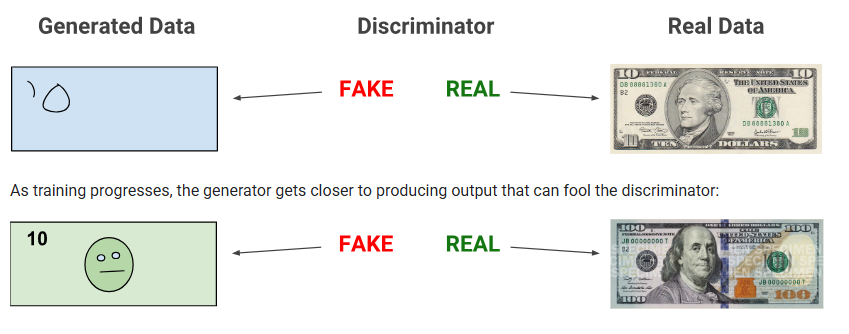

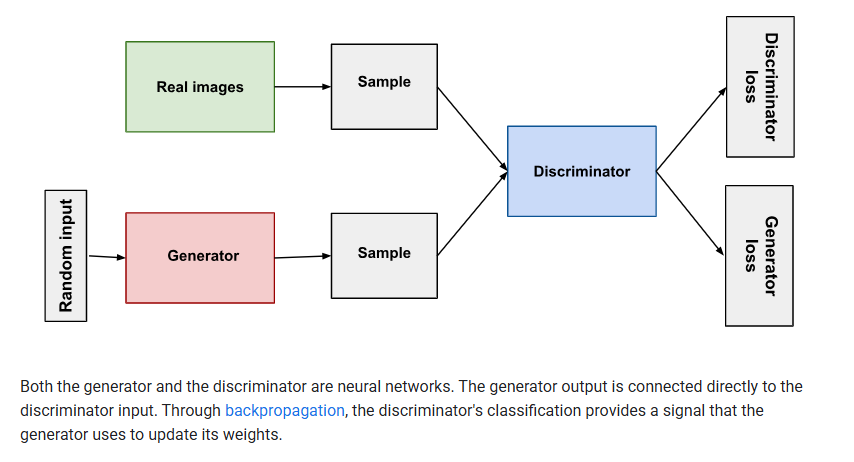

In [ ]:
import os
from IPython.display import Image, display
display(Image(filename="GAN1.PNG"))
display(Image(filename="GANarchitecture.PNG"))

## Core Applications of GANs in Architecture

Architects utilize GANs across multiple stages of a project, transforming abstract data into visual assets:

- 2D Plan Generation: Algorithms analyze thousands of historical apartment layouts to instantly generate optimal room placements, structural grids, and core layouts based on a site boundary.

- Style Transfer and Materialization: Image-to-image GANs (like Pix2Pix) instantly convert rough hand sketches, massing diagrams, or massing models into photorealistic architectural renderings with materials, lighting, and landscaping.

- Site and Master Planning: GANs analyze urban contexts, zoning laws, and street networks to generate synthetic master plans that balance density, green space, and solar access.

- Structural and Facade Optimization: GANs generate intricate panelization systems or optimized structural trusses by learning patterns from performative engineering models.

## How Architects Use GANs for Form Generation

Form generation via GANs typically shifts from traditional 3D modeling (like Rhino or Revit) to a data-driven design loop.

Architects use GANs for form generation through three primary methodologies:

1. Voxel-Based 3D Form Generation (3D-GAN): Just as 2D GANs operate on pixels, 3D GANs operate on voxels (3D pixels).

- The Process: Architects input 3D voxel models of existing building typologies (e.g., skyscrapers, pavilions, or houses) into a 3D-GAN.

- The Outcome: The generator creates entirely new 3D spatial solids and spatial voids that match the volumetric complexity of the training data. This allows architects to explore highly organic or radically complex massing options that are difficult to model manually.

2. Cross-Sectional and Plan-Extrusion Generation : Many architects generate 3D forms by stacking or morphing 2D planes generated by a GAN.

- The Process: A 2D GAN is trained on building footprints, elevation silhouettes, or structural sections.

- The Outcome: The architect generates a series of morphing variations of these shapes. By importing these vector paths into Rhino/Grasshopper, they can loft, extrude, or sweep the curves into complex, fluid 3D building forms.

3. Image-to-Image Massing Transformation (Pix2Pix)

Architects use conditional GANs (cGANs) to bridge the gap between simple spatial diagrams and complex architectural massing.

- The Process: The user inputs a simple, color-coded functional block model (e.g., Red = Retail, Blue = Residential, Yellow = Circulation).

- The Outcome: The GAN interprets the color-coded programmatic massing and generates a detailed architectural facade and complex building form that respects those spatial boundaries.

## A Typical GAN Workflow for an Architect

[ Dataset Collection ] ──► Gather 1,000+ images/models of a specific style (e.g., Brutalist) <br>
          │<br>
          ▼<br>
[ Training Phase ]     ──► Generator creates forms ◄──► Discriminator critiques them<br>
          │<br>
          ▼<br>
[ Generation ]         ──► AI outputs a unique 2D image or 3D voxel grid<br>
          │<br>
          ▼<br>
[ Translation ]        ──► Import to Rhino/Grasshopper to convert vectors into 3D geometry

https://developer.nvidia.com/blog/archigan-generative-stack-apartment-building-design/

https://papers.cumincad.org/data/works/att/acadia18_156.pdf


# Natural Language Processing

!pip install nltk

### Download standard NLTK data resources for text parsing
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


### Step 1: Text Preprocessing
Raw text must be cleaned and broken down before a computer can process it. We will perform:
1. **Tokenization**: Splitting sentences into individual words.
2. **Lowercasing**: Standardizing text case.
3. **Stopword Removal**: Dropping highly common semantic filler words (e.g., "the", "is").
4. **Lemmatization**: Reducing words to their base dictionary forms (e.g., "running" becomes "run").

## Text to Numbers

https://towardsdatascience.com/the-art-of-tokenization-breaking-down-text-for-ai-43c7bccaed25/


In [ ]:
https://towardsdatascience.com/wp-content/uploads/2024/09/1mkvzSPMiX5FZcuQjFe2B6w.png

In [ ]:
#!pip install nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Sample raw document corpus
raw_documents = [
    "The quick brown foxes are jumping over the lazy dogs!",
    "Natural Language Processing with Python is incredibly fun.",
    "I absolutely hate waiting in long lines at the store."
]

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Tokenize & lowercase
    tokens = word_tokenize(text.lower())
    # 2. Filter out non-alphanumeric tokens and remove stopwords
    cleaned_tokens = [word for word in tokens if word.isalnum() and word not in stop_words]
    # 3. Apply lemmatization
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in cleaned_tokens]
    return " ".join(lemmatized_tokens)

# Process our sample corpus
processed_documents = [preprocess_text(doc) for doc in raw_documents]

# Display comparison results
for original, processed in zip(raw_documents, processed_documents):
    print(f"Original : {original}")
    print(f"Processed: {processed}\n")

## Step 2: Vectorization (Feature Extraction)
Machine learning models require numerical matrices instead of raw strings.
We use **TF-IDF (Term Frequency-Inverse Document Frequency)** via [Scikit-learn's TfidfVectorizer](https://colab.research.google.com/github/dr-mushtaq/Natural-language-processing/blob/main/Natural_Language_Processing.ipynb).
This technique scales down weights for words that appear frequently across all documents, highlighting unique identifiers.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF Vectorizer matrix
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(processed_documents)

# Convert numerical matrices into a scannable Pandas DataFrame
feature_names = vectorizer.get_feature_names_out()
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

print("Vocabulary features extracted:")
print(feature_names)
print("\nTF-IDF Numerical Representation Matrix:")
df_tfidf

### Text Embeddings

https://stackoverflow.blog/2023/11/09/an-intuitive-introduction-to-text-embeddings/


https://cohere.com/llmu/text-embeddings



(Step 3: Intent / Sentiment Classification)

## Step 3: Train a Basic Text Classifier
Now we use our vectorized features to predict text sentiment.
We will train a simple Naive Bayes model to map input language to binary classification sentiments.

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Training text corpus mapping to explicit classes (1 = Positive, 0 = Negative)
train_docs = [
    "I love this software, it is amazing",
    "This is an excellent and helpful tool",
    "Horrible experience, completely broken",
    "Waste of time, I highly dislike it"
]
train_labels = [1, 1, 0, 0] # 1: Positive, 0: Negative

# Preprocess training corpus text data
processed_train = [preprocess_text(doc) for doc in train_docs]

# Fit Vectorizer and transform texts to numerical matrices
clf_vectorizer = TfidfVectorizer()
X_train = clf_vectorizer.fit_transform(processed_train)

# Initialize and train our Machine Learning Classifier
model = MultinomialNB()
model.fit(X_train, train_labels)

# Evaluate model performance against unseen target sentences
test_docs = ["I love this helpful tool", "This system is broken and horrible"]
processed_test = [preprocess_text(doc) for doc in test_docs]
X_test = clf_vectorizer.transform(processed_test)

# Predict targets
predictions = model.predict(X_test)

# Print results
for doc, pred in zip(test_docs, predictions):
    sentiment = "Positive" if pred == 1 else "Negative"
    print(f"Text: '{doc}' --> Predicted Sentiment: {sentiment}")

# NLP with Transformers

https://console.paperspace.com/github/nlp-with-transformers/notebooks/blob/main/01_introduction.ipynb?file=01_introduction.ipynb


# Transformer Architecture

https://jalammar.github.io/illustrated-transformer/

https://poloclub.github.io/transformer-explainer/

https://research.google/blog/transformer-a-novel-neural-network-architecture-for-language-understanding/

In [ ]:
# 1. Install the official Google Gen AI Python SDK
#!pip install -q google-genai

import os
from google import genai
from google.colab import userdata

# 2. Safely retrieve your API key from Colab Secrets
try:
    api_key = userdata.get('GEMINI_API_KEY')
except Exception:
    print("Make sure you added 'GEMINI_API_KEY' to your Colab Secrets (the 🔑 icon)!")
    api_key = None

if api_key:
    # 3. Initialize the Gemini Client
    client = genai.Client(api_key=api_key)

    # 4. Generate text with an architecture-focused prompt
    prompt = """
    Act as a senior design principal. Provide three innovative conceptual design ideas
    for a modern, sustainable residential project located in a dense urban environment.
    Focus on passive heating/cooling, biophilic design elements, and spatial efficiency.
    """

    print(f"Prompt: {prompt}\nGenerating response...\n")

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )

    # 5. Output the result
    print("--- Model Response ---")
    print(response.text)

Prompt: 
    Act as a senior design principal. Provide three innovative conceptual design ideas 
    for a modern, sustainable residential project located in a dense urban environment. 
    Focus on passive heating/cooling, biophilic design elements, and spatial efficiency.
    
Generating response...

--- Model Response ---
Alright team, let's look at how we can push the boundaries for sustainable urban living. The challenge is clear: density, modernity, and a deep commitment to environmental stewardship and human well-being. We need to create homes that don't just exist in the city, but actively contribute to a healthier urban ecosystem.

Here are three distinct conceptual directions, each leveraging passive strategies, biophilia, and spatial ingenuity to deliver a truly innovative residential experience:

---

### Concept 1: The "Living Lumen" Tower – Biophilic Cores & Stack Effect Voids

**Core Idea:** Reimagining the central core of a high-rise not just as circulation and services

# Natural Language Processing for Design Briefs

Natural Language Processing (NLP) is a branch of artificial intelligence that gives computers the ability to understand, interpret, and manipulate human language.

In architecture, NLP bridges the gap between descriptive human intentions (written text) and computational design tools. Instead of manually translating a client's written design brief into spatial requirements, an architect can use NLP algorithms to automatically read the document and extract key quantitative parameters.

## How NLP Transforms a Design Brief

When an NLP model reads an architectural design brief, it breaks down raw text into structured design data:

[ Raw Design Brief ] ──► "We need a 3-bedroom sustainable house with a large open kitchen." <br>
          │<br>
          ▼<br>
[ NLP Processing   ] ──► Tokenization, Part-of-Speech Tagging, Entity Recognition<br>
          │<br>
          ▼<br>
[ Structured Data  ] ──► Program: Residential | Rooms: 3 Bedrooms, 1 Kitchen | Attribute: Open, Sustainable<br>


## Key NLP Mechanics for Architects

- Tokenization: Breaking down sentences into individual words or phrases (tokens) to analyze them systematically.

- Named Entity Recognition (NER): Identifying and classifying key terms in a text. For example, recognizing "200 sqm" as a Spatial Dimension, "Lobby" as a Room Type, or "Concrete" as a Material.

- Sentiment & Intent Analysis: Evaluating the tone or priority of a brief to understand which design requirements are strict constraints and which are flexible desires.

### How to use Large Language Models (LLMs) like GPT to automatically convert a messy client email into a structured spatial programming matrix

To convert an unorganized client email into a structured spatial programming matrix, you can combine a Large Language Model (LLM) like GPT with Python's structured data outputs.

The most robust way to guarantee the AI outputs clean, reliable tables without random text is by using Structured Outputs (JSON Mode or Pydantic validation) through the official OpenAI API.

In [ ]:
import os
import json
import pandas as pd
from google.colab import userdata
from openai import OpenAI

# 1. Initialize OpenAI client
# Ensure your API key is stored securely in Colab's "Secrets" panel (key icon)
client = OpenAI(api_key=userdata.get('OPENAI_API_KEY'))

# 2. Simulated messy client email
client_email = """
Hi Team, thinking about the new workspace layout. We definitely need a main welcoming
lobby, maybe around 400 sq ft, with high durability flooring. For the main operations,
let's do an open-plan office area for 25 people—give them plenty of space, maybe 1,500 sq ft,
and keep it acoustic-friendly. We also need a couple of small meeting rooms, say 2 rooms
at 150 sq ft each for collaborative syncs. Oh, and don't forget a secure server room,
100 sq ft max, completely private and strictly controlled access. Let me know what you think!
"""

# 3. Define the precise JSON schema you want the model to follow
spatial_schema = {
    "type": "object",
    "properties": {
        "spaces": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "Room_Name": {"type": "string"},
                    "Count": {"type": "integer"},
                    "Area_Per_Unit_SqFt": {"type": "integer"},
                    "Total_Area_SqFt": {"type": "integer"},
                    "Primary_Function": {"type": "string"},
                    "Privacy_Level": {"type": "string", "enum": ["Public", "Semi-Private", "Private"]},
                    "Special_Requirements": {"type": "string"}
                },
                "required": ["Room_Name", "Count", "Area_Per_Unit_SqFt", "Total_Area_SqFt", "Primary_Function", "Privacy_Level", "Special_Requirements"],
                "additionalProperties": False
            }
        }
    },
    "required": ["spaces"],
    "additionalProperties": False
}

# 4. Call the LLM with system instructions and schema enforcement
response = client.chat.completions.create(
    model="gpt-4o-mini",  # Highly cost-effective and accurate for extraction tasks
    messages=[
        {
            "role": "system",
            "content": "You are an expert architectural programmer. Analyze the messy client email and extract spatial programmatic requirements into the requested JSON schema. Calculate total areas carefully based on unit counts."
        },
        {
            "role": "user",
            "content": client_email
        }
    ],
    response_format={
        "type": "json_schema",
        "json_schema": {
            "name": "spatial_programming_matrix",
            "strict": True,
            "schema": spatial_schema
        }
    }
)

# 5. Convert the enforced JSON directly into a structured Pandas DataFrame
json_data = json.loads(response.choices[0].message.content)
df_matrix = pd.DataFrame(json_data["spaces"])

# Calculate a quick total target area sum
total_building_footprint = df_matrix['Total_Area_SqFt'].sum()

print(f"--- EXTRACTED SPATIAL PROGRAMMING MATRIX (Total Target: {total_building_footprint} SqFt) ---\n")
print(df_matrix.to_string(index=False))

# 6. Optional: Export to Excel/CSV for Rhino Grasshopper or Revit Dynamo pipelines
# df_matrix.to_csv("spatial_program.csv", index=False)

## Above workflow

- Schema Enforcement: Setting strict: True forces the LLM to strip away all conversational fluff ("Hi team", "Let me know what you think") and outputs only raw mathematical or text values mapping directly to your columns.

- Typology Standardization: The schema enforces strict rules—like choosing a Privacy_Level only from the list ["Public", "Semi-Private", "Private"]. This keeps data uniformly structured for downstream workflows.

- Mathematical Math Fixes: The system prompt ensures that if a client asks for "2 rooms at 150 sq ft each," the model correctly computes the Total_Area_SqFt as 300 rather than just copying the single number.

### How to link this specific pandas DataFrame output back into your Grasshopper pipeline script to automatically draw the rooms as 3D boxes.

To link your extracted pandas programming matrix into Rhino Grasshopper and automatically generate 3D spatial boxes, you need to save the DataFrame as a CSV file and read it via a GH Python Script component inside Grasshopper.

Step 1: Export the DataFrame from PythonAdd these lines to the bottom of your previous OpenAI script to save the spatial data to a known file path.

In [ ]:
csv_path = "C:/data/spatial_program.csv"
df_matrix.to_csv(csv_path, index=False)
print(f"Data saved to {csv_path} for Grasshopper pipeline.")

Step 2: Set Up the Grasshopper CanvasDrop a GH Python Script component onto your Grasshopper canvas.Create one input parameter and name it file_path. Set its type hint to String and access to Item Access.Create a Panel component, paste your CSV path (C:/data/spatial_program.csv), and connect it to the file_path input.Set the output parameter name to boxes.

Step 3: Paste the Code into the GH Python ComponentDouble-click the GH Python Script component, delete any default placeholder code, and paste the script below. This code reads the CSV, calculates a packaging grid layout, and draws a 3D box for each room based on its required area.

In [ ]:
import os
import math
import Rhino.Geometry as rg

def create_program_boxes(path):
    # Fallback output list for Rhino geometry
    generated_boxes = []

    # 1. Check if the pipeline file exists
    if not os.path.exists(path):
        print("Waiting for CSV data pipeline...")
        return generated_boxes

    # 2. Parse the CSV file manually (avoiding external pandas dependency inside Rhino)
    with open(path, 'r') as f:
        lines = f.readlines()

    # Extract column names from header row
    header = lines[0].strip().split(',')

    # Locate column indices dynamically
    try:
        idx_name = header.index("Room_Name")
        idx_area = header.index("Total_Area_SqFt")
        idx_count = header.index("Count")
    except ValueError:
        print("Error: Missing expected columns in CSV pipeline.")
        return generated_boxes

    # 3. Layout Grid Variables
    current_x = 0.0
    current_y = 0.0
    spacing = 10.0      # Separation distance between rooms (in feet/units)
    default_height = 10.0 # Default architectural ceiling height
    row_max_width = 100.0 # Wrap to next row if layout gets too wide

    # 4. Generate 3D Box for each row in the matrix
    for line in lines[1:]:
        row = line.strip().split(',')
        if len(row)  row_max_width:
                current_x = 0.0
                current_y += side_length + spacing

    return generated_boxes

# Execute the pipeline execution trigger
if file_path:
    boxes = create_program_boxes(file_path)

Step 4: Verify the Parametric Pipeline

[ Python Script / LLM ] ──► (Saves CSV file)<br>
                                  │<br>
                                  ▼<br>
[ Grasshopper Panel   ] ──► "C:/data/spatial_program.csv"<br>
                                  │<br>
                                  ▼<br>
[ GH Python Script    ] ──► Parses columns ──► Calculates √Area ──► Outputs 3D Brep Solids<br>

As soon as you run your AI data script, the CSV updates. Grasshopper detects the file modification instantly, calculates the square root of the target areas, and constructs perfectly scaled 3D bounding boxes on your Rhino canvas.

## Few-Shot Prompting with a Markdown/JSON Schema Enforcement

```
You are an expert architectural programmer and data analyst. Your task is to analyze the unstructured, messy client email provided at the bottom of this prompt and transform it into a perfectly structured Spatial Programming Matrix.

### Structure Rules:
Generate a clean, markdown table containing exactly these 7 columns:
1. Room_Name (Standardized, clear room names)
2. Count (Total quantity of this specific room type)
3. Area_Per_Unit_SqFt (The floor area of a single unit, as an integer)
4. Total_Area_SqFt (The mathematically verified total: Count multiplied by Area_Per_Unit_SqFt)
5. Primary_Function (A brief description of what happens in that space)
6. Privacy_Level (Strictly classify as exactly one of these: "Public", "Semi-Private", or "Private")
7. Special_Requirements (A summary of any performance, aesthetic, material, or security notes mentioned)

### Processing Instructions:
- Strip away all conversational fluff, salutations, and generic feedback from the email.
- If a space is mentioned without a specific square footage, make an educated architectural estimate based on standard programming guidelines and explicitly label it with "(Estimated)" next to the number.
- Ensure you double-check the mathematical calculation: Count x Area_Per_Unit_SqFt must equal Total_Area_SqFt.
- At the very bottom of the output, print a separate line calculating the sum of all Total_Area_SqFt as: "Total Building Target Area: [SUM] SqFt".

### Strict Formatting Rule:
Output ONLY the markdown table and the final total area calculation. Do not include introductory text, conversational pleasantries, or concluding explanations. Start your response directly with the table header.

---
### INPUT CLIENT EMAIL TO ANALYZE:
[Paste Client Email Here]
```